# 03 — kNN: Prediction, Validation, and Error Analysis

We can now compute distances efficiently. This notebook completes the classifier: select neighbors, vote on labels, choose `k` with validation data, evaluate once on held-out test data, and inspect mistakes.

## Learning objectives

- turn a distance matrix into class predictions;
- implement deterministic majority voting;
- distinguish model fitting, hyperparameter selection, and final evaluation;
- select `k` using validation accuracy without consulting test labels;
- interpret errors made by raw-pixel nearest neighbors.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

## 1. Prepare independent subsets

The training subset supplies stored examples. The validation subset comes from the remaining official training images. The test subset comes from CIFAR-10's official test split.

A seeded random subset is not guaranteed to contain exactly the same number of examples from every class, but it should be reasonably representative at this size.

In [2]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)

X_train_full = train_dataset.data
y_train_full = np.asarray(train_dataset.targets)
X_test_full = test_dataset.data
y_test_full = np.asarray(test_dataset.targets)

NUM_TRAIN = 5_000
NUM_VALIDATION = 500
NUM_TEST = 500

train_permutation = rng.permutation(len(X_train_full))
train_indices = train_permutation[:NUM_TRAIN]
validation_indices = train_permutation[NUM_TRAIN:NUM_TRAIN + NUM_VALIDATION]
test_indices = rng.choice(len(X_test_full), size=NUM_TEST, replace=False)

X_train_images = X_train_full[train_indices]
y_train = y_train_full[train_indices]
X_validation_images = X_train_full[validation_indices]
y_validation = y_train_full[validation_indices]
X_test_images = X_test_full[test_indices]
y_test = y_test_full[test_indices]

X_train = X_train_images.reshape(NUM_TRAIN, -1).astype(np.float32)
X_validation = X_validation_images.reshape(NUM_VALIDATION, -1).astype(np.float32)
X_test = X_test_images.reshape(NUM_TEST, -1).astype(np.float32)

print("train:", X_train.shape, y_train.shape)
print("validation:", X_validation.shape, y_validation.shape)
print("test:", X_test.shape, y_test.shape)

train: (5000, 3072) (5000,)
validation: (500, 3072) (500,)
test: (500, 3072) (500,)


## 2. Vectorized squared L2 distances

This is the implementation derived in [the previous notebook](./02_knn_vectorized_distances.ipynb). Computing validation distances once lets us reuse them for every candidate value of `k`.

In [3]:
def squared_l2_distances(X_query: np.ndarray, X_stored: np.ndarray) -> np.ndarray:
    if X_query.ndim != 2 or X_stored.ndim != 2:
        raise ValueError("Inputs must be two-dimensional")
    if X_query.shape[1] != X_stored.shape[1]:
        raise ValueError("Inputs must have equal feature dimensions")

    query_norms = np.sum(X_query**2, axis=1, keepdims=True)
    stored_norms = np.sum(X_stored**2, axis=1, keepdims=True).T
    distances = query_norms + stored_norms - 2 * (X_query @ X_stored.T)
    return np.maximum(distances, 0)


validation_distances = squared_l2_distances(X_validation, X_train)
assert validation_distances.shape == (NUM_VALIDATION, NUM_TRAIN)
print("validation distance matrix:", validation_distances.shape)

validation distance matrix: (500, 5000)


## 3. Exercise 1 — Select nearest neighbors

Implement a function that returns the indices of the `k` smallest distances in every row, ordered from nearest to farthest. Validate that `k` is an integer in `[1, N_stored]`.

Start with `np.argsort(..., axis=1)`. It sorts every row and is easy to understand. More advanced partial sorting can be explored later.

In [ ]:
def nearest_neighbor_indices(distances: np.ndarray, k: int) -> np.ndarray:
    """Return ordered indices of the k nearest stored examples per query."""
    if distances.ndim != 2:
        raise ValueError("Distances must be a two-dimensional array")
    if not isinstance(k, int):
        raise ValueError("k must be an integer")
    if k <= 0:
        raise ValueError("k must be a positive integer")
    if k > distances.shape[1]:
        raise ValueError("k cannot be greater than the number of stored examples")
    
    nearest = np.argsort(distances, axis=1)[:, :k]
    return nearest

In [5]:
example_distances = np.array([[9.0, 1.0, 4.0, 2.0], [0.5, 8.0, 3.0, 2.0]])
expected_indices = np.array([[1, 3, 2], [0, 3, 2]])
np.testing.assert_array_equal(
    nearest_neighbor_indices(example_distances, k=3),
    expected_indices,
)
print("Neighbor selection check passed.")

Neighbor selection check passed.


## 4. Exercise 2 — Majority voting

For each query, retrieve the labels of its `k` nearest stored examples and predict the most frequent label. `np.bincount` counts nonnegative integer labels; `np.argmax` returns the first maximum, so ties are resolved deterministically in favor of the smaller class label.

The numerical class ID has no semantic ordering, so this tie rule is a reproducibility convention—not evidence that a smaller label is more likely.

In [16]:
def predict_from_distances(
    distances: np.ndarray,
    stored_labels: np.ndarray,
    k: int,
    num_classes: int = 10,
) -> np.ndarray:
    """Predict one class label per query using majority vote."""
    nearest_indices = nearest_neighbor_indices(distances, k)
    canditate_labels = stored_labels[nearest_indices]
    
    predictions = np.array(
        [
            np.argmax(
                np.bincount(labels, minlength=num_classes)
            ) for labels in canditate_labels
        ]
    )

    return predictions

In [17]:
example_distances

array([[9. , 1. , 4. , 2. ],
       [0.5, 8. , 3. , 2. ]])

In [18]:
np.array([4, 2, 2, 4])[nearest_neighbor_indices(example_distances, 3)]

array([[2, 4, 2],
       [4, 4, 2]])

In [19]:
np.bincount([2, 4, 2], minlength=10), np.argmax(np.bincount([2, 4, 2], minlength=10))

(array([0, 0, 2, 0, 1, 0, 0, 0, 0, 0]), np.int64(2))

In [20]:
example_labels = np.array([4, 2, 2, 4])

# Query 0's three nearest labels are [2, 4, 2], so class 2 wins.
# Query 1 with k=2 has labels [4, 4], so class 4 wins.
np.testing.assert_array_equal(
    predict_from_distances(example_distances, example_labels, k=3),
    [2, 4],
)

# With k=2, query 0 has a 2-versus-4 tie; the smaller label wins.
assert predict_from_distances(example_distances[:1], example_labels, k=2)[0] == 2
print("Voting and tie-breaking checks passed.")

Voting and tie-breaking checks passed.


## 5. Exercise 3 — Accuracy

Classification accuracy is the fraction of predictions equal to their targets:

$$\text{accuracy}=\frac{\text{number of correct predictions}}{\text{number of examples}}.
$$

Return a value between 0 and 1. Reject arrays with different shapes and empty inputs.

In [33]:
def accuracy(predictions: np.ndarray, targets: np.ndarray) -> float:
    if predictions.shape != targets.shape:
        raise ValueError("Predictions and targets must have the same shape")
    if predictions.size == 0:
        raise ValueError("Predictions and targets must not be empty")
    return float(np.mean(predictions == targets))


assert accuracy(np.array([1, 0, 3, 2]), np.array([1, 2, 3, 2])) == 0.75
print("Accuracy check passed.")

Accuracy check passed.


## 6. Select `k` with validation data

`k` is a **hyperparameter**: it is chosen rather than learned from stored examples. We evaluate candidate values using validation labels. Test labels must not influence this decision.

If multiple candidates achieve the same best validation accuracy, the code below chooses the smaller `k` because `max` preserves the first encountered maximum.

In [22]:
K_CHOICES = [1, 3, 5, 7, 9, 15]
validation_accuracies = {}

for k in K_CHOICES:
    predictions = predict_from_distances(validation_distances, y_train, k)
    validation_accuracies[k] = accuracy(predictions, y_validation)
    print(f"k={k:>2}: validation accuracy = {validation_accuracies[k]:.3f}")

best_k = max(K_CHOICES, key=validation_accuracies.get)
print("selected k:", best_k)

k= 1: validation accuracy = 0.254
k= 3: validation accuracy = 0.258
k= 5: validation accuracy = 0.264
k= 7: validation accuracy = 0.238
k= 9: validation accuracy = 0.240
k=15: validation accuracy = 0.258
selected k: 5


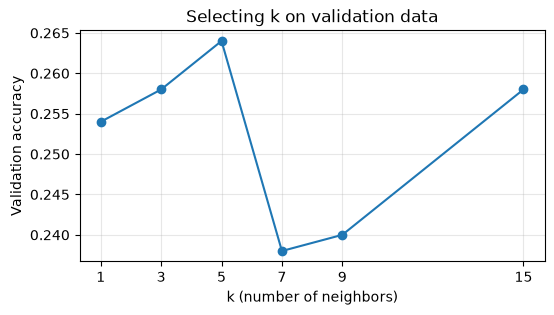

In [23]:
fig, axis = plt.subplots(figsize=(6, 3))
axis.plot(K_CHOICES, [validation_accuracies[k] for k in K_CHOICES], marker="o")
axis.set(
    xlabel="k (number of neighbors)",
    ylabel="Validation accuracy",
    title="Selecting k on validation data",
)
axis.set_xticks(K_CHOICES)
axis.grid(alpha=0.3)
plt.show()

### Exercise 4 — Interpret validation results

In a new Markdown cell, answer:

1. Which `k` was selected, and what validation accuracy did it achieve?
2. Why should `k` not be selected using test accuracy?
3. What qualitative difference do you expect between very small and very large `k`?
4. Would testing more `k` values guarantee better generalization? Why or why not?

1. k=5 is selected. it achieved 26.4% accuracy which is much higher than random guess (~10%)
2. cause that is data leakage
3. lower k leads to high variance and low bias (tend to overfit) while large k effects high bias and low variance
4. no, it does not guarantee better generalization. From above graph k=5 seems to be optimal choice. But k=5 is the best candidate tested on this particular validation subset. We cannot conclude it is universally optimal.
Trying more values does not guarantee better generalization because repeated selection can overfit the validation set. Cross-validation provides a more reliable estimate.

## 7. Final test evaluation

Only now—after fixing `best_k`—do we compute test predictions. This provides a less biased estimate of performance on unseen data. Running many test-driven experiments would gradually turn the test set into another validation set.

In [24]:
test_distances = squared_l2_distances(X_test, X_train)
test_predictions = predict_from_distances(test_distances, y_train, best_k)
test_accuracy = accuracy(test_predictions, y_test)
print(f"test accuracy with k={best_k}: {test_accuracy:.3f}")

test accuracy with k=5: 0.264


## 8. Inspect errors and neighbors

Aggregate accuracy says how often the classifier succeeds, but not why it fails. The following visualization shows misclassified test queries in the first column and their five nearest training images to the right. Green neighbor titles match the true class; red titles do not.

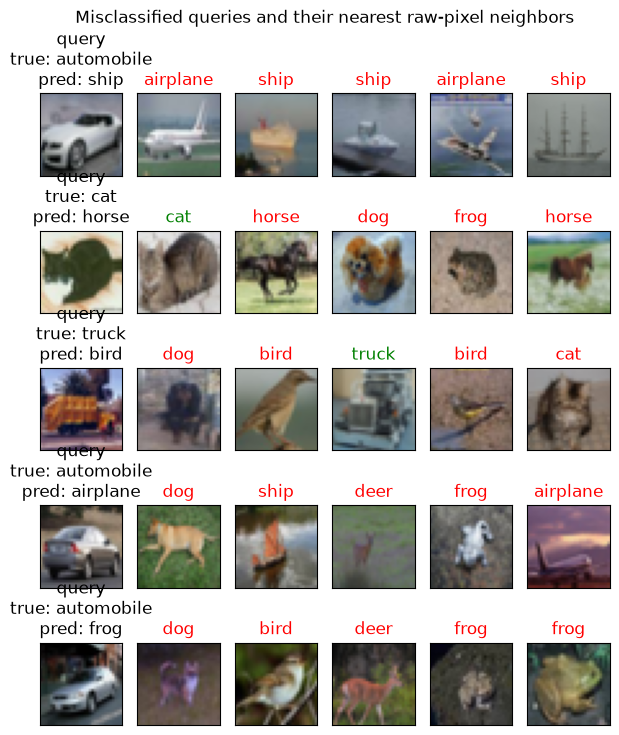

In [27]:
NUM_ERRORS_TO_SHOW = 5
NUM_NEIGHBORS_TO_SHOW = 5
error_indices = np.flatnonzero(test_predictions != y_test)[:NUM_ERRORS_TO_SHOW]
neighbor_indices = nearest_neighbor_indices(
    test_distances[error_indices],
    NUM_NEIGHBORS_TO_SHOW,
)

fig, axes = plt.subplots(
    len(error_indices),
    NUM_NEIGHBORS_TO_SHOW + 1,
    figsize=(6, 1.5 * len(error_indices)),
    squeeze=False,
)

for row, error_index in enumerate(error_indices):
    true_label = y_test[error_index]
    axes[row, 0].imshow(X_test_images[error_index])
    axes[row, 0].set_title(
        f"query\ntrue: {CLASS_NAMES[true_label]}\npred: {CLASS_NAMES[test_predictions[error_index]]}"
    )

    for column, neighbor_index in enumerate(neighbor_indices[row], start=1):
        neighbor_label = y_train[neighbor_index]
        axes[row, column].imshow(X_train_images[neighbor_index])
        axes[row, column].set_title(
            CLASS_NAMES[neighbor_label],
            color="green" if neighbor_label == true_label else "red",
        )

for axis in axes.flat:
    axis.set_xticks([])
    axis.set_yticks([])

fig.suptitle("Misclassified queries and their nearest raw-pixel neighbors")
plt.tight_layout()
plt.show()

## 9. Confusion matrix

A confusion matrix summarizes which classes are confused with one another. Rows represent true classes and columns represent predicted classes. A diagonal cell counts correct predictions; an off-diagonal cell `(i, j)` counts examples of true class `i` predicted as class `j`.

Each row should sum to the number of evaluated test examples belonging to that true class.

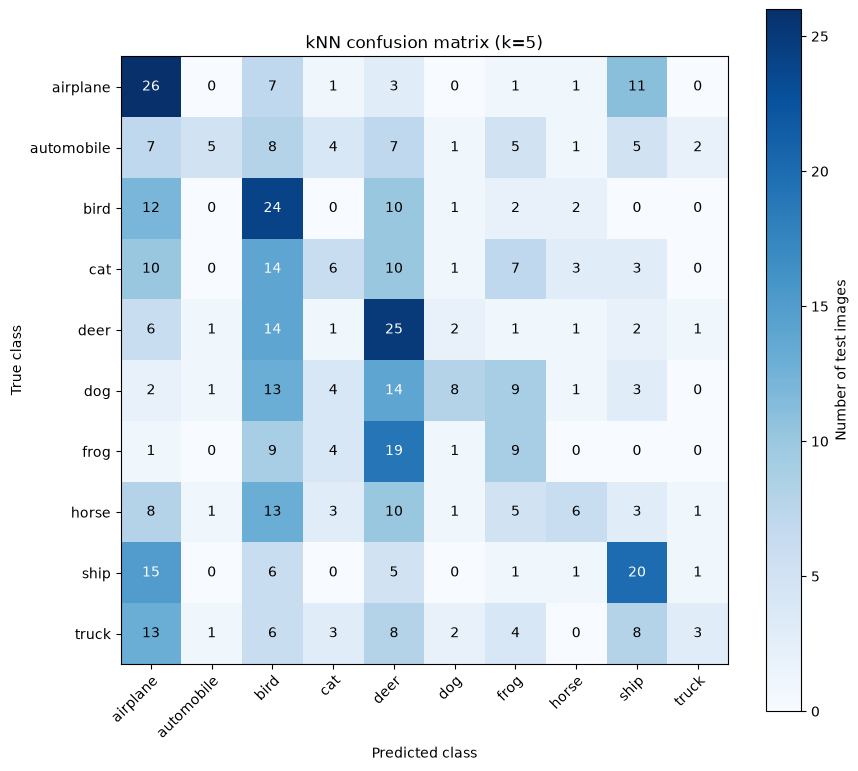

In [35]:
num_classes = len(CLASS_NAMES)
confusion_matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
np.add.at(confusion_matrix, (y_test, test_predictions), 1)

assert confusion_matrix.shape == (10, 10)
assert confusion_matrix.sum() == len(y_test)
np.testing.assert_array_equal(
    confusion_matrix.sum(axis=1),
    np.bincount(y_test, minlength=num_classes),
)
assert np.trace(confusion_matrix) == np.sum(test_predictions == y_test)

fig, axis = plt.subplots(figsize=(9, 8))
image = axis.imshow(confusion_matrix, cmap="Blues")
fig.colorbar(image, ax=axis, label="Number of test images")

axis.set(
    xticks=np.arange(num_classes),
    yticks=np.arange(num_classes),
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    xlabel="Predicted class",
    ylabel="True class",
    title=f"kNN confusion matrix (k={best_k})",
)
plt.setp(axis.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

threshold = confusion_matrix.max() / 2
for true_label in range(num_classes):
    for predicted_label in range(num_classes):
        count = confusion_matrix[true_label, predicted_label]
        axis.text(
            predicted_label,
            true_label,
            str(count),
            ha="center",
            va="center",
            color="white" if count > threshold else "black",
        )

fig.tight_layout()
plt.show()

Read the matrix in both directions:

- Across a row: where examples of one true class were sent.
- Down a column: which true classes contributed to one predicted class.

Identify the largest off-diagonal cell. It represents the most frequent directed confusion—for example, `cat → dog` is distinct from `dog → cat`.

## 10. Are frequent training classes predicted more often?

Because our 5,000-image training subset was sampled randomly, its class counts are close but not necessarily identical. We can compare three distributions on the same 500-example scale:

- **training-proportional expectation:** how many predictions each class would receive if prediction frequency exactly followed its share of training data;
- **test truth:** how many test examples actually belong to each class;
- **model predictions:** how often kNN predicted each class.

A Pearson correlation summarizes linear association between training counts and prediction counts. With only ten classes, it is descriptive rather than conclusive, and correlation does not establish causation. Class appearance, raw-pixel geometry, and neighbor voting can also influence prediction frequency.

Correlation between training and prediction counts: 0.350

Class counts:
  airplane: train= 473, expected= 47.3, test= 50, predicted=100
automobile: train= 542, expected= 54.2, test= 45, predicted=  9
      bird: train= 535, expected= 53.5, test= 51, predicted=114
       cat: train= 482, expected= 48.2, test= 54, predicted= 26
      deer: train= 523, expected= 52.3, test= 54, predicted=111
       dog: train= 473, expected= 47.3, test= 55, predicted= 17
      frog: train= 502, expected= 50.2, test= 43, predicted= 44
     horse: train= 469, expected= 46.9, test= 51, predicted= 16
      ship: train= 518, expected= 51.8, test= 49, predicted= 55
     truck: train= 483, expected= 48.3, test= 48, predicted=  8


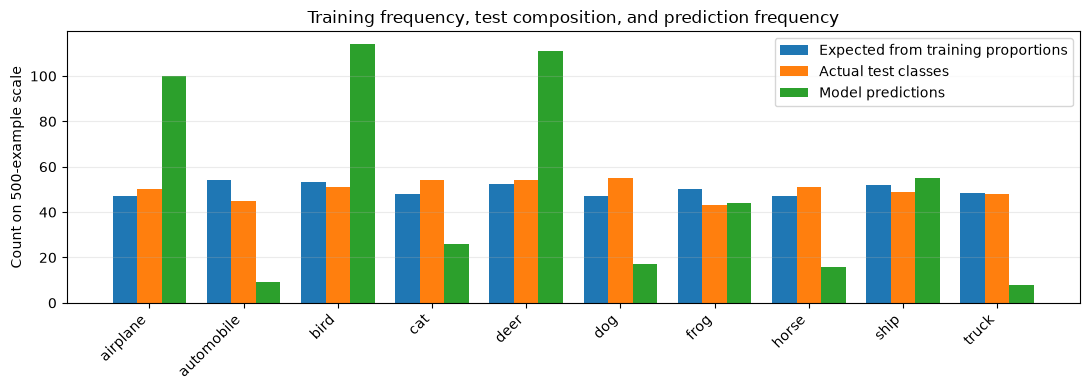

In [36]:
train_class_counts = np.bincount(y_train, minlength=num_classes)
test_class_counts = np.bincount(y_test, minlength=num_classes)
prediction_counts = np.bincount(test_predictions, minlength=num_classes)

# Put training frequencies on the same 500-example scale as test predictions.
expected_from_train_proportions = train_class_counts / len(y_train) * len(y_test)
count_correlation = np.corrcoef(train_class_counts, prediction_counts)[0, 1]

print(f"Correlation between training and prediction counts: {count_correlation:.3f}")
print("\nClass counts:")
for label, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name:>10}: train={train_class_counts[label]:4d}, "
        f"expected={expected_from_train_proportions[label]:5.1f}, "
        f"test={test_class_counts[label]:3d}, "
        f"predicted={prediction_counts[label]:3d}"
    )

positions = np.arange(num_classes)
width = 0.26
fig, axis = plt.subplots(figsize=(11, 4))
axis.bar(
    positions - width,
    expected_from_train_proportions,
    width,
    label="Expected from training proportions",
)
axis.bar(positions, test_class_counts, width, label="Actual test classes")
axis.bar(positions + width, prediction_counts, width, label="Model predictions")
axis.set(
    xticks=positions,
    xticklabels=CLASS_NAMES,
    ylabel="Count on 500-example scale",
    title="Training frequency, test composition, and prediction frequency",
)
plt.setp(axis.get_xticklabels(), rotation=45, ha="right")
axis.legend()
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

Interpret the comparison carefully:

- Similar training and prediction bars would be consistent with the hypothesis that training frequency matters.
- Large prediction differences despite similar training bars suggest that the classifier's distance metric and class appearance matter more here.
- Test counts provide context: prediction counts need not be uniform if the sampled test subset itself is not perfectly balanced.

A stronger causal test would deliberately rebalance or resample the training set while holding the same validation/test examples fixed, then repeat the experiment.

## Final reflection

Add a Markdown cell answering:

1. What does kNN "training" consist of? Where is most computation performed?
2. Why can increasing `k` make predictions less sensitive to individual noisy examples?
3. What happens during a vote tie, and why is that policy arbitrary?
4. From the error visualization, what visual properties seem to drive raw-pixel similarity?
5. Why can two images of the same object class have a large raw-pixel distance?
6. Summarize the proper roles of training, validation, and test data in this experiment.

1. trainig is just storing all samples in memory. all computation performed on prediciton step
2. cause model considers more nearest samples during prediction meaning it is less sensitive to individual samples
3. it selects the lowest label number. np.argmax selects the smallest class ID during a tie. Class IDs are merely identifiers and have no meaningful order, so there is no statistical reason to prefer the smaller one.
4. colors, position on image
5. colors, position on image. Two images of the same class can have a large pixel distance because the object may be translated, rotated, scaled, differently posed, differently illuminated, or placed against another background. Raw-pixel L2 distance does not understand that they represent the same semantic object.
6. trainig data used for model training, validation for hyperparams tuninig, test for final model evaluation